# 📦 Rectangle Packing — Reinforcement Learning Agent

This notebook trains a **MaskablePPO** agent to pack randomly sized rectangles into a fixed-size zone.

| Component | Details |
|-----------|---------|
| Environment | Custom Gymnasium `RectanglePackingEnv` |
| Algorithm | `MaskablePPO` (sb3-contrib) — invalid actions masked per step |
| State | Flattened binary grid + current item dims + remaining count |
| Action | `(rotation, x, y)` encoded as a single Discrete index |
| Reward | +area on valid placement · −2 on invalid · +200 bonus when all packed |


## 1 · Environment Setup — Imports & kernel check

In [1]:
import os
import importlib
import sys

# ── Point Python at our project files ─────────────────────────────────────
PROJECT = os.path.dirname(os.path.abspath("__file__"))
if PROJECT not in sys.path:
    sys.path.insert(0, PROJECT)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects
%matplotlib inline
matplotlib.rcParams["figure.dpi"] = 100

import gymnasium as gym
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback

# Reload local modules on every run (picks up any edits to .py files)
import packing_env
import visualize
importlib.reload(packing_env)
importlib.reload(visualize)

from packing_env import RectanglePackingEnv
from visualize import plot_packing, plot_episode_grid, plot_metrics

print(f"Python        : {sys.version.split()[0]}")
print(f"NumPy         : {np.__version__}")
print(f"Gymnasium     : {gym.__version__}")
print("sb3-contrib   : OK")
print("✓ All imports successful")


Python        : 3.12.3
NumPy         : 2.4.3
Gymnasium     : 1.2.3
sb3-contrib   : OK
✓ All imports successful


## 2 · Environment Demo — Random Agent

Instantiate the environment, run one random episode, and render the packing result so we can see the problem before training.

In [8]:
# ── Configuration ──────────────────────────────────────────────────────────
ENV_CONFIG = dict(
    zone_w        = 4,   # zone width  (grid cells)
    zone_h        = 4,   # zone height (grid cells)
    n_items       = 50,   # rectangles to pack per episode
    min_item_size = 1,    # min side length
    max_item_size = 2,    # max side length
)

# ── Random-agent episode ────────────────────────────────────────────────────
env = RectanglePackingEnv(**ENV_CONFIG, seed=42)
obs, _ = env.reset()

print(f"Zone          : {env.zone_w} × {env.zone_h} = {env.zone_w*env.zone_h} cells")
print(f"Items to pack : {env.n_items}  ➜  {env.items}")
print(f"Observation   : shape {obs.shape}  (grid={env.zone_w*env.zone_h}, +3 for item dims & remaining)")
print(f"Action space  : {env.action_space}  ({2}×{env.n_positions} = {env.action_space.n})")
print()

total_reward = 0
done = False
step = 0
while not done:
    action = env.action_space.sample()          # purely random
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    total_reward += reward
    step += 1

print(f"Random agent finished in {step} steps")
print(f"  Placed      : {info['placed']}/{info['total']}")
print(f"  Utilisation : {info['utilisation']*100:.1f}%")
print(f"  Total reward: {total_reward:.1f}")


Zone          : 4 × 4 = 16 cells
Items to pack : 50  ➜  [(1, 2), (2, 1), (1, 2), (1, 2), (1, 1), (2, 2), (2, 2), (2, 2), (2, 1), (2, 1), (2, 1), (1, 2), (2, 2), (1, 2), (2, 1), (1, 1), (1, 2), (2, 1), (2, 2), (1, 2), (1, 2), (2, 1), (1, 2), (1, 2), (2, 2), (2, 1), (1, 1), (1, 1), (2, 1), (2, 2), (2, 2), (1, 2), (1, 1), (2, 1), (1, 1), (2, 1), (1, 1), (2, 1), (1, 1), (2, 2), (2, 1), (1, 2), (2, 2), (1, 1), (2, 2), (1, 2), (2, 1), (2, 1), (1, 2), (2, 1)]
Observation   : shape (19,)  (grid=16, +3 for item dims & remaining)
Action space  : Discrete(33)  (2×16 = 33)

Random agent finished in 54 steps
  Placed      : 5/50
  Utilisation : 56.2%
  Total reward: -89.0


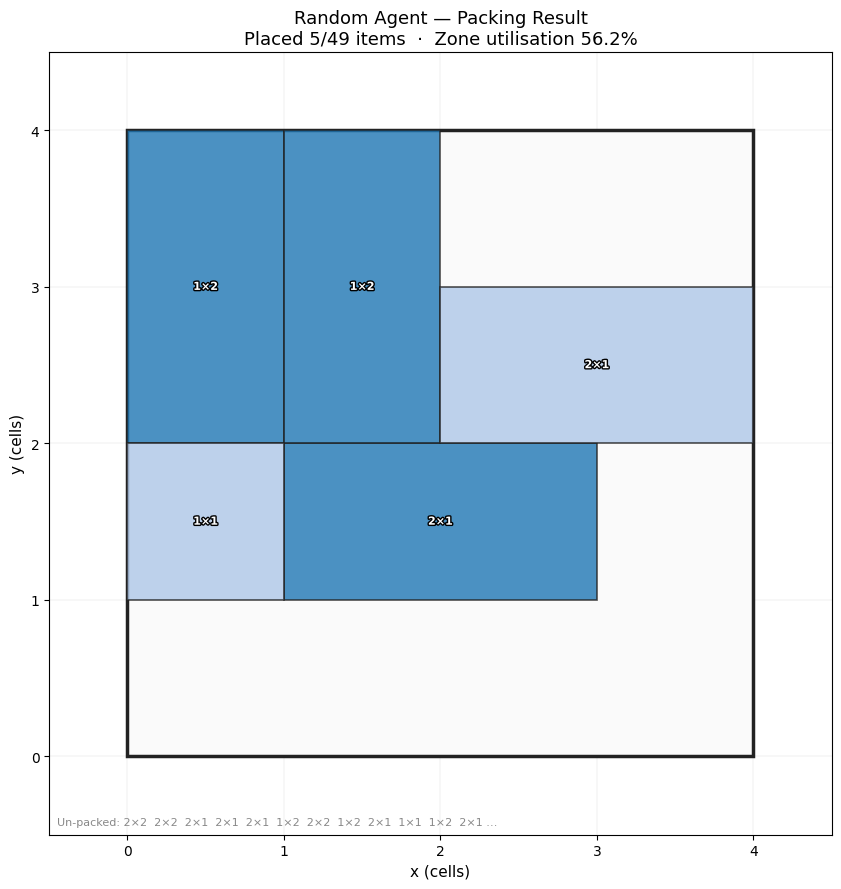

In [9]:
# ── Visualise the random agent's result ────────────────────────────────────
remaining = env.items[env.current_idx:]
fig, ax = plot_packing(
    placed_items    = env.placed_items,
    remaining_items = remaining,
    zone_w          = env.zone_w,
    zone_h          = env.zone_h,
    title           = "Random Agent — Packing Result",
)
plt.show()


## 3 · Training — MaskablePPO

**Why MaskablePPO?**  
In bin-packing many actions are invalid (overlap or out-of-bounds).  
`MaskablePPO` applies a per-step **action mask** so the agent never samples illegal placements, which speeds up learning dramatically.

The reward signal is:
$$R_t = \begin{cases} w \times h & \text{(valid placement)} \\ -2 & \text{(invalid)} \\ +200 & \text{(all items packed)} \end{cases}$$

In [11]:

# ── Metrics collector callback ──────────────────────────────────────────────
class MetricsCallback(BaseCallback):
    """Collect per-episode reward, utilisation, and placement rate."""
    def __init__(self):
        super().__init__()
        self.ep_rewards      = []
        self.ep_utilisation  = []
        self.ep_placed_ratio = []

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.ep_rewards.append(info["episode"]["r"])
            if "utilisation" in info:
                self.ep_utilisation.append(info["utilisation"] * 100)
            if "placed" in info and "total" in info and info["total"] > 0:
                self.ep_placed_ratio.append(info["placed"] / info["total"] * 100)
        return True


def make_masked_env(cfg, seed=0):
    def _init():
        env = RectanglePackingEnv(**cfg, seed=seed)
        env = ActionMasker(env, lambda e: e.action_masks())
        return Monitor(env)
    return _init


# ── Training knobs ──────────────────────────────────────────────────────────
TOTAL_TIMESTEPS = 500_000   # increase for better results (e.g. 500_000)
N_ENVS          = 5

print(f"Training MaskablePPO for {TOTAL_TIMESTEPS:,} timesteps on {N_ENVS} parallel envs …")
print("This will take ~2–4 min on CPU. Watch the progress prints below.\n")

vec_env    = DummyVecEnv([make_masked_env(ENV_CONFIG, seed=i) for i in range(N_ENVS)])
metrics_cb = MetricsCallback()

model = MaskablePPO(
    "MlpPolicy",
    vec_env,
    verbose        = 1,          # prints iteration summary
    learning_rate  = 0.0003,
    n_steps        = 1024,
    batch_size     = 256,
    n_epochs       = 150,
    gamma          = 0.99,
    gae_lambda     = 0.95,
    clip_range     = 0.2,
    ent_coef       = 0.01,
)
# model = MaskablePPO.load("models/packing_agent", env=vec_env)

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=metrics_cb, progress_bar=False)

os.makedirs("models", exist_ok=True)
model.save("models/packing_agent")
print("\n✓ Training complete — model saved to  models/packing_agent.zip")
print(f"  Episodes recorded : {len(metrics_cb.ep_rewards)}")
if metrics_cb.ep_rewards:
    last_n = min(50, len(metrics_cb.ep_rewards))
    print(f"  Last {last_n} eps — mean reward       : {np.mean(metrics_cb.ep_rewards[-last_n:]):.1f}")
    print(f"  Last {last_n} eps — mean utilisation  : {np.mean(metrics_cb.ep_utilisation[-last_n:]):.1f}%")
    print(f"  Last {last_n} eps — mean placed ratio : {np.mean(metrics_cb.ep_placed_ratio[-last_n:]):.1f}%")


Training MaskablePPO for 500,000 timesteps on 5 parallel envs …
This will take ~2–4 min on CPU. Watch the progress prints below.

Using cuda device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 53.2     |
|    ep_rew_mean     | -75.3    |
| time/              |          |
|    fps             | 3730     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 5120     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 53.4       |
|    ep_rew_mean          | -75.6      |
| time/                   |            |
|    fps                  | 976        |
|    iterations           | 2          |
|    time_elapsed         | 10         |
|    total_timesteps      | 10240      |
| train/                  |            |
|    approx_kl            | 0.01992708 |
|    clip_fraction        | 0.26       |
|    clip_range     

## 4 · Training Curves

Plot reward, utilisation, and placement rate over all episodes.

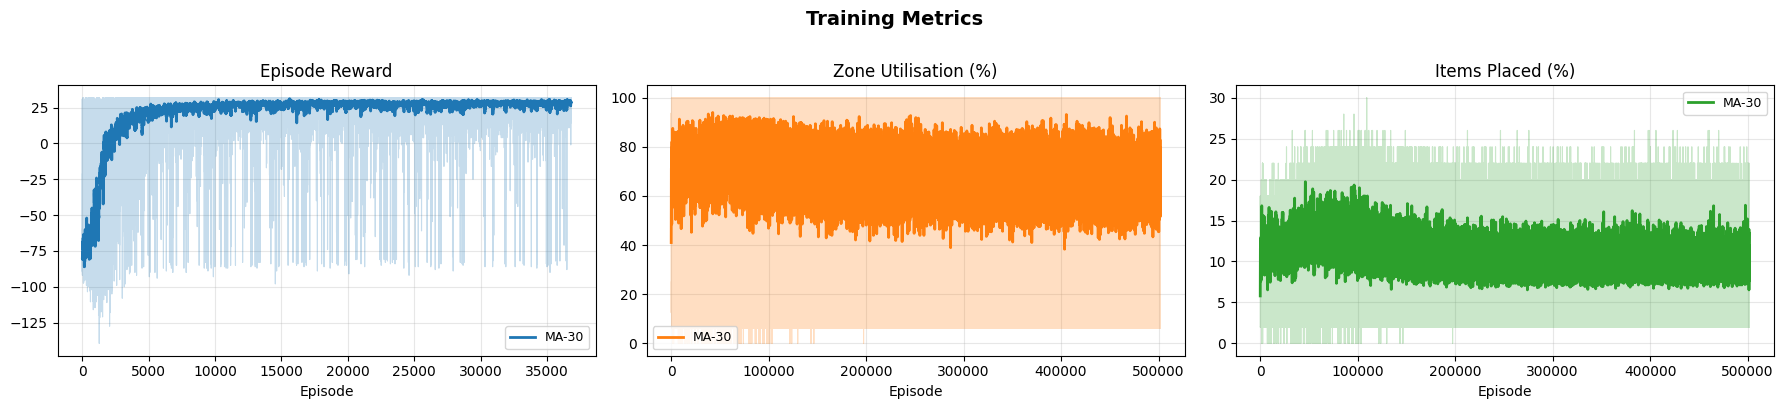

In [12]:
fig = plot_metrics(
    {
        "Episode Reward"       : metrics_cb.ep_rewards,
        "Zone Utilisation (%)" : metrics_cb.ep_utilisation,
        "Items Placed (%)"     : metrics_cb.ep_placed_ratio,
    },
    smoothing=30,
)
plt.show()


## 5 · Evaluate the Trained Agent

Run the trained agent deterministically on 6 fresh episodes and visualise each packing result.

In [13]:
def run_episode(model, env_cfg, seed, deterministic=True):
    """Run one episode with the trained model, return episode data dict."""
    eval_env = RectanglePackingEnv(**env_cfg, seed=seed)
    eval_env = ActionMasker(eval_env, lambda e: e.action_masks())
    obs, _ = eval_env.reset()

    done = False
    total_reward = 0.0
    while not done:
        mask = eval_env.action_masks()
        action, _ = model.predict(obs, action_masks=mask, deterministic=deterministic)
        obs, reward, terminated, truncated, info = eval_env.step(int(action))
        done = terminated or truncated
        total_reward += reward

    return {
        "placed_items"   : eval_env.env.placed_items,      # unwrap ActionMasker
        "remaining_items": eval_env.env.items[eval_env.env.current_idx:],
        "zone_w"         : eval_env.env.zone_w,
        "zone_h"         : eval_env.env.zone_h,
        "utilisation"    : info["utilisation"] * 100,
        "placed"         : info["placed"],
        "total"          : info["total"],
        "reward"         : total_reward,
        "seed"           : seed,
    }

N_EVAL = 6
episodes = []
print("Evaluating trained agent …")
for s in range(N_EVAL):
    ep = run_episode(model, ENV_CONFIG, seed=100 + s)
    episodes.append(ep)
    print(f"  Seed {ep['seed']:4d}  |  placed {ep['placed']}/{ep['total']}"
          f"  |  util {ep['utilisation']:5.1f}%  |  reward {ep['reward']:+.0f}")

avg_util  = np.mean([e["utilisation"] for e in episodes])
avg_place = np.mean([e["placed"] / e["total"] * 100 for e in episodes])
print(f"\nAverage utilisation : {avg_util:.1f}%")
print(f"Average placed rate : {avg_place:.1f}%")


Evaluating trained agent …
  Seed  100  |  placed 6/50  |  util 100.0%  |  reward +32
  Seed  101  |  placed 7/50  |  util 100.0%  |  reward +32
  Seed  102  |  placed 9/50  |  util 100.0%  |  reward +28
  Seed  103  |  placed 8/50  |  util 100.0%  |  reward +27
  Seed  104  |  placed 9/50  |  util 100.0%  |  reward +29
  Seed  105  |  placed 7/50  |  util 100.0%  |  reward +30

Average utilisation : 100.0%
Average placed rate : 15.3%


## 6 · Visualise Packing Results — Grid View

Each subplot shows one evaluation episode with colour-coded rectangles and the zone utilisation.

Saved → results_grid.png


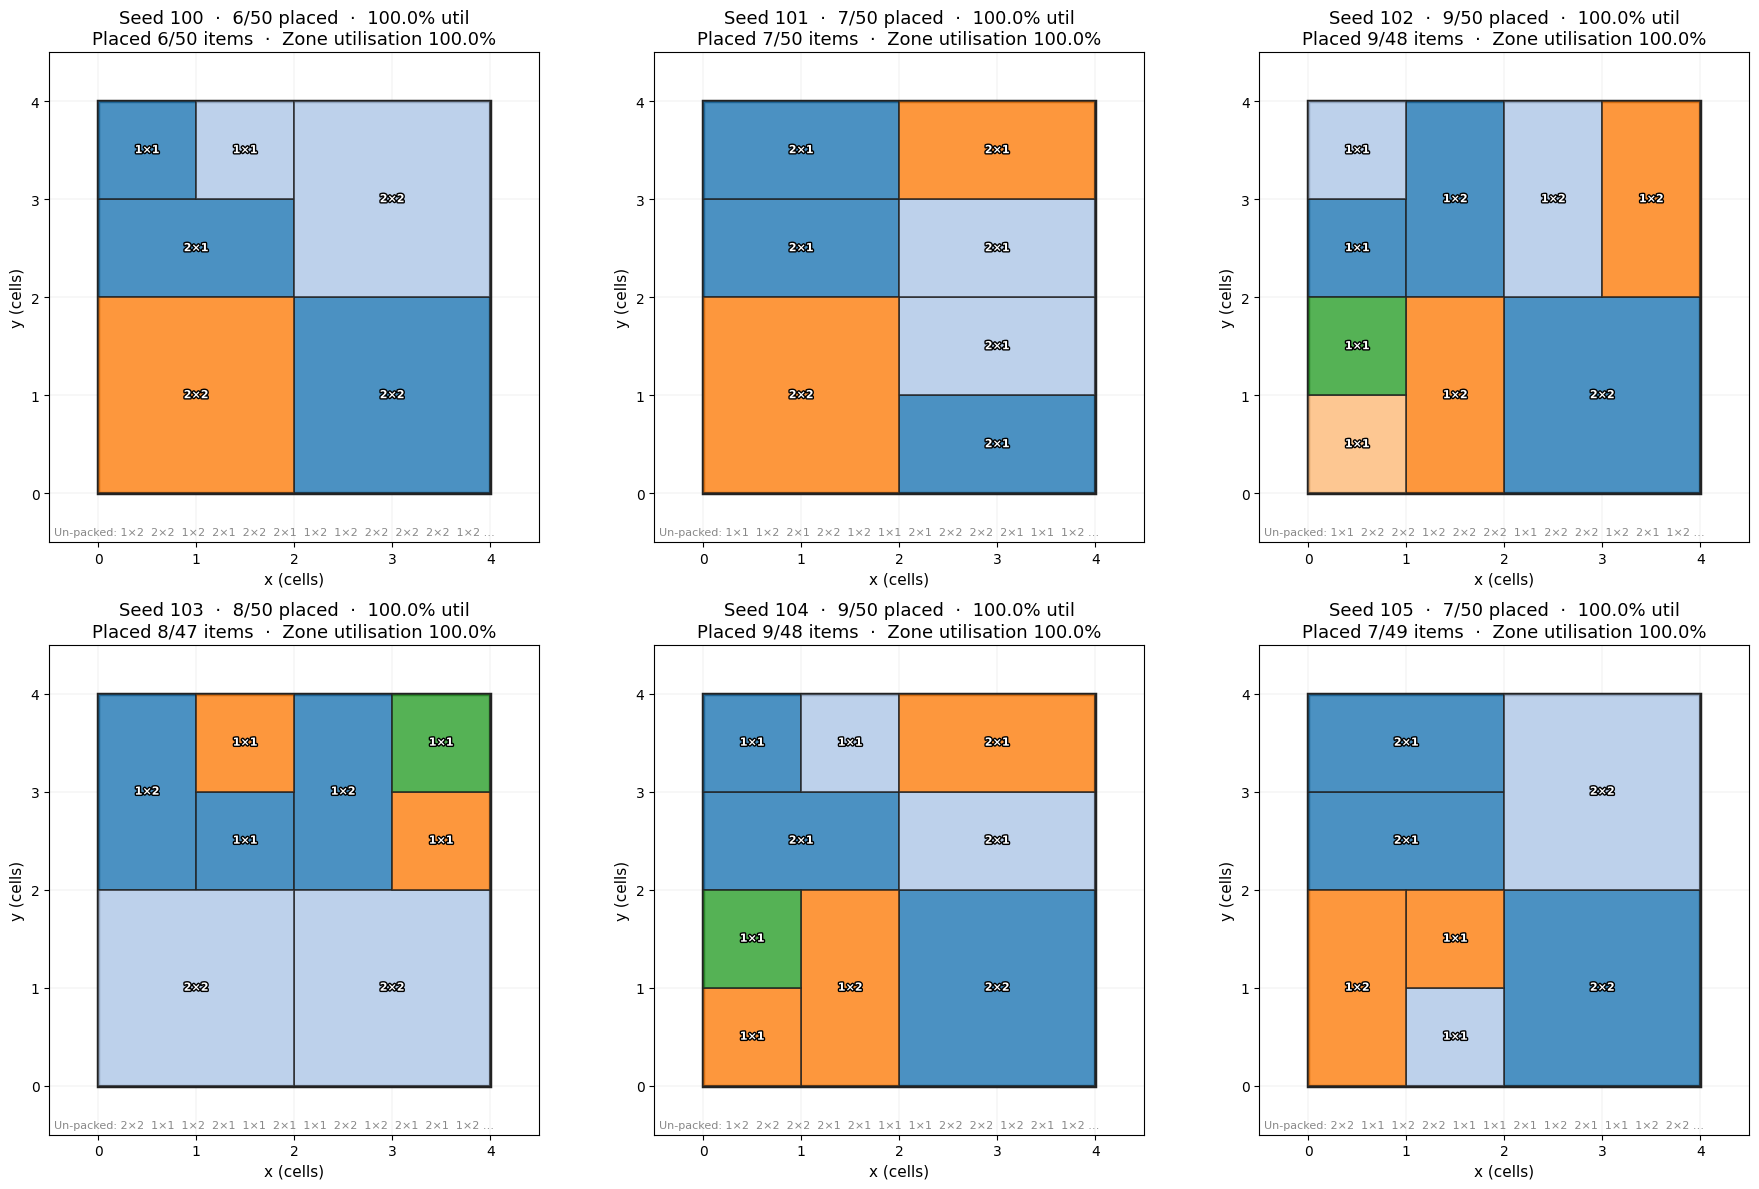

Saved → results_grid.png


In [14]:
# Add a human-readable title for each subplot
for ep in episodes:
    ep["title"] = (
        f"Seed {ep['seed']}  ·  {ep['placed']}/{ep['total']} placed"
        f"  ·  {ep['utilisation']:.1f}% util"
    )

fig = plot_episode_grid(episodes, cols=3, save_path="results_grid.png")
plt.show()
print("Saved → results_grid.png")


In [22]:
# ── Show unpacked items for each episode ────────────────────────────────────
print("\nUnpacked Items by Episode:")
print("=" * 60)

for ep in episodes:
    remaining = ep["remaining_items"]
    
    if remaining:
        # Count items by size
        from collections import Counter
        size_counts = Counter()
        for w, h in remaining:
            # Normalize (smaller dimension first) for cleaner display
            size = tuple(sorted([w, h]))
            size_counts[size] += 1
        
        # Format nicely
        unpacked_str = "  ".join(
            f"{count}:{w}×{h}" 
            for (w, h), count in sorted(size_counts.items())
        )
        print(f"Seed {ep['seed']:3d}  |  Unpacked: {unpacked_str}")
    else:
        print(f"Seed {ep['seed']:3d}  |  ✓ All items packed!")

print("=" * 60)


Unpacked Items by Episode:
Seed 100  |  Unpacked: 2:1×2  1:1×3  1:1×5  1:1×6  1:1×7  1:2×5  2:2×6  1:2×7  2:2×8  1:2×9  1:2×10  1:3×6  2:3×7  1:3×9  1:3×10  2:4×5  1:4×6  1:4×7  1:4×9  1:4×10  1:5×7  2:5×8  1:5×10  1:6×6  1:6×8  2:6×9  2:6×10  1:7×7  2:7×9  1:7×10  1:8×10  1:9×9  1:9×10  1:10×10
Seed 101  |  Unpacked: 2:1×2  2:1×3  2:1×4  1:1×5  1:1×6  1:1×7  2:1×8  1:1×10  1:2×4  1:2×5  1:2×6  3:3×4  2:3×5  2:3×7  1:3×9  2:4×5  1:4×6  1:4×7  1:4×8  1:4×10  3:5×7  2:5×9  1:5×10  1:6×7  1:6×8  1:6×9  1:6×10  2:8×9  1:8×10  2:9×9
Seed 102  |  Unpacked: 1:1×3  2:1×9  1:1×10  2:2×2  1:2×5  2:2×7  1:2×8  1:2×9  2:2×10  2:3×3  1:3×5  1:3×6  1:3×8  2:3×10  1:4×5  3:4×6  1:4×7  2:4×8  1:5×9  1:5×10  1:6×6  1:6×7  1:6×9  2:6×10  1:7×7  1:7×9  2:7×10  1:8×9  1:8×10  2:10×10
Seed 103  |  Unpacked: 3:1×2  1:1×4  1:1×5  3:1×7  1:1×9  2:1×10  1:2×3  1:2×4  1:2×5  1:2×6  1:2×7  1:2×8  1:2×9  1:2×10  4:3×4  1:3×8  1:3×10  2:4×5  1:4×7  1:4×9  1:5×6  1:5×7  3:5×9  1:6×6  1:6×7  1:6×8  1:7×8  1:7×9  1:

## 7 · Best vs Worst Episode — Side-by-Side

Highlight the best (highest utilisation) and worst episode from the evaluation run.

/media/ramyar/New Volume1/Git/RL/visualize.py:134: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_157690/3446423360.py:24: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("best_vs_worst.png", dpi=150, bbox_inches="tight")
/media/ramyar/New Volume1/Git/RL/.venv-1/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


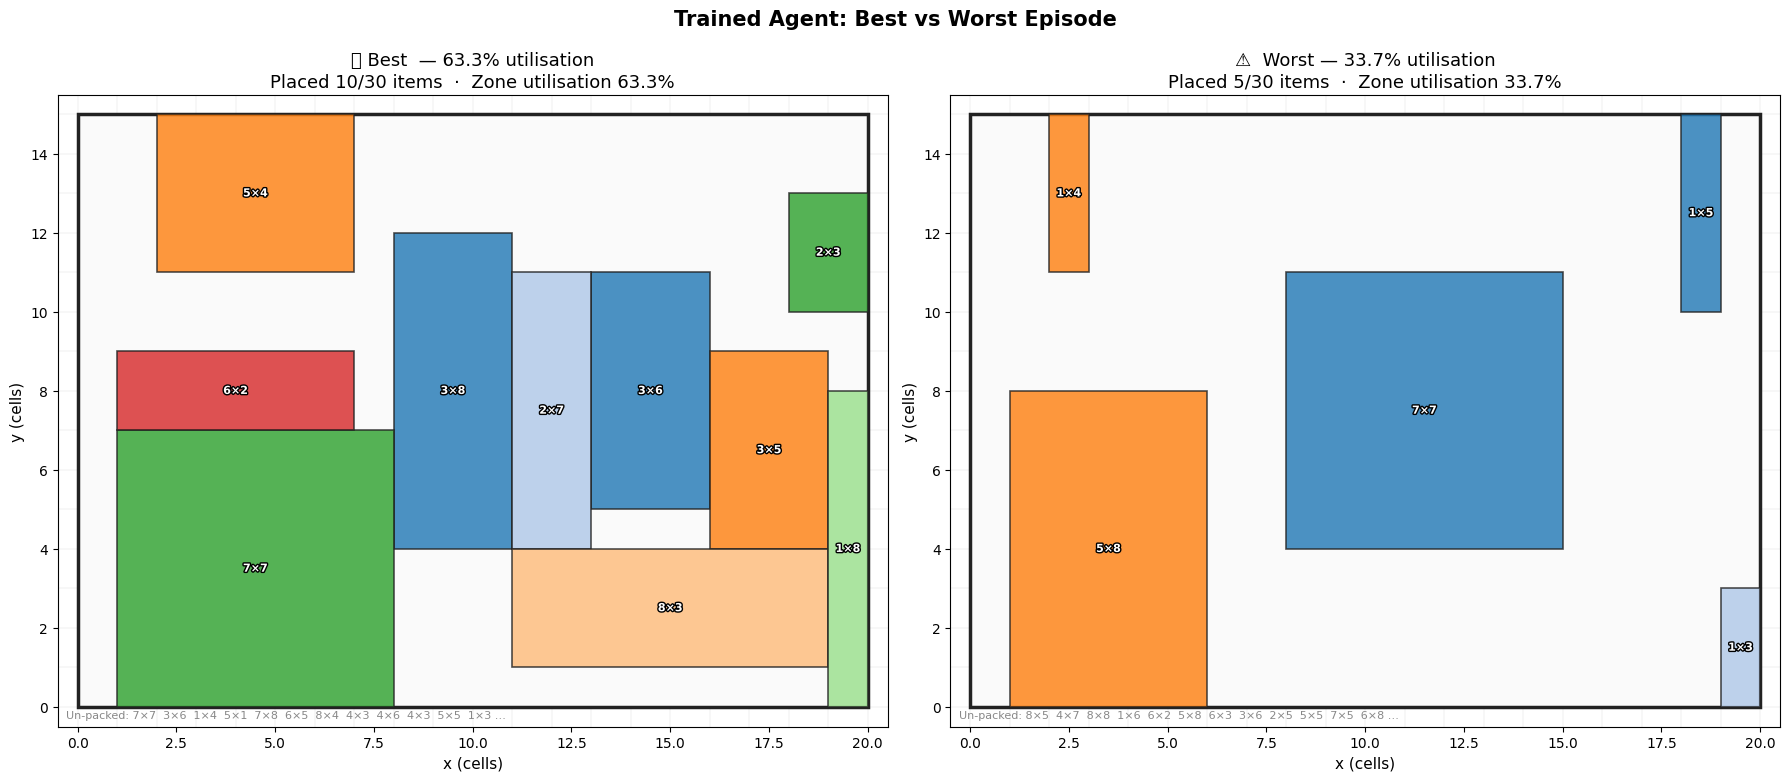

Saved → best_vs_worst.png


In [12]:
best  = max(episodes, key=lambda e: e["utilisation"])
worst = min(episodes, key=lambda e: e["utilisation"])

fig, (ax_b, ax_w) = plt.subplots(1, 2, figsize=(18, 8))

plot_packing(
    placed_items    = best["placed_items"],
    remaining_items = best["remaining_items"],
    zone_w=best["zone_w"], zone_h=best["zone_h"],
    title=f"🏆 Best  — {best['utilisation']:.1f}% utilisation",
    ax=ax_b,
)

plot_packing(
    placed_items    = worst["placed_items"],
    remaining_items = worst["remaining_items"],
    zone_w=worst["zone_w"], zone_h=worst["zone_h"],
    title=f"⚠  Worst — {worst['utilisation']:.1f}% utilisation",
    ax=ax_w,
)

fig.suptitle("Trained Agent: Best vs Worst Episode", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("best_vs_worst.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → best_vs_worst.png")


## 8 · Summary & Next Steps

### What was built

| File | Purpose |
|------|---------|
| `packing_env.py` | Custom Gymnasium env — zone, items, grid, action masking |
| `train.py` | CLI training script with checkpoints & evaluation callbacks |
| `visualize.py` | Reusable plotting utilities (single episode, grid, metrics) |
| `rectangle_packing_rl.ipynb` | This interactive training & visualisation notebook |

### Ideas to improve performance
- **More timesteps** — increase `TOTAL_TIMESTEPS` to 500k–1M
- **Larger zone / more items** — scale `zone_w`, `zone_h`, `n_items`
- **Curriculum learning** — start with few large items, gradually increase difficulty
- **Observation enrichment** — add a sorted list of remaining item dimensions to the state
- **Graph/CNN policy** — replace the default MLP with a CNN over the 2-D grid
- **Rotation penalty** — discourage unnecessary 90° rotations